In [1]:
# TASK 1 - DATA PIPELINE DEVELOPMENT
# Intern: Vivek Dipak Kshirsagar | ID: CTIS6665
# Codtech IT Solutions | Data Science Internship

import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("✅ All Libraries Imported Successfully!")

✅ All Libraries Imported Successfully!


In [2]:
# STEP 2 - DATA CREATION (Sample Dataset)

data = {
    'Age': [25, 30, np.nan, 45, 28, np.nan, 52, 33, 41, 29],
    'Salary': [30000, 45000, 50000, np.nan, 35000, 60000, np.nan, 48000, 52000, 31000],
    'Department': ['IT', 'HR', 'IT', 'Finance', np.nan, 'HR', 'Finance', 'IT', np.nan, 'HR'],
    'Experience': [2, 5, 7, 15, 3, 8, 20, 6, 12, 4],
    'Promoted': [0, 1, 1, 1, 0, 1, 1, 1, 1, 0]
}

df = pd.DataFrame(data)
print("✅ Dataset Created!")
print("\n📊 Raw Data (with missing values):")
print(df)
print(f"\n❌ Missing Values:\n{df.isnull().sum()}")

✅ Dataset Created!

📊 Raw Data (with missing values):
    Age   Salary Department  Experience  Promoted
0  25.0  30000.0         IT           2         0
1  30.0  45000.0         HR           5         1
2   NaN  50000.0         IT           7         1
3  45.0      NaN    Finance          15         1
4  28.0  35000.0        NaN           3         0
5   NaN  60000.0         HR           8         1
6  52.0      NaN    Finance          20         1
7  33.0  48000.0         IT           6         1
8  41.0  52000.0        NaN          12         1
9  29.0  31000.0         HR           4         0

❌ Missing Values:
Age           2
Salary        2
Department    2
Experience    0
Promoted      0
dtype: int64


In [3]:
# STEP 3 - DATA PREPROCESSING & PIPELINE

# Handle missing values for numeric columns
num_imputer = SimpleImputer(strategy='mean')
df['Age'] = num_imputer.fit_transform(df[['Age']])
df['Salary'] = num_imputer.fit_transform(df[['Salary']])

# Handle missing values for categorical column
cat_imputer = SimpleImputer(strategy='most_frequent')
df['Department'] = cat_imputer.fit_transform(df[['Department']]).ravel()

# Encode categorical column
le = LabelEncoder()
df['Department'] = le.fit_transform(df['Department'])

print("✅ Missing Values Handled!")
print(f"\n📊 Cleaned Data:\n{df}")
print(f"\n❌ Missing Values After Cleaning:\n{df.isnull().sum()}")

✅ Missing Values Handled!

📊 Cleaned Data:
      Age   Salary  Department  Experience  Promoted
0  25.000  30000.0           2           2         0
1  30.000  45000.0           1           5         1
2  35.375  50000.0           2           7         1
3  45.000  43875.0           0          15         1
4  28.000  35000.0           1           3         0
5  35.375  60000.0           1           8         1
6  52.000  43875.0           0          20         1
7  33.000  48000.0           2           6         1
8  41.000  52000.0           1          12         1
9  29.000  31000.0           1           4         0

❌ Missing Values After Cleaning:
Age           0
Salary        0
Department    0
Experience    0
Promoted      0
dtype: int64


In [4]:
# STEP 4 - SCALING + PIPELINE + MODEL TRAINING

X = df[['Age', 'Salary', 'Department', 'Experience']]
y = df['Promoted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("✅ Pipeline Trained Successfully!")
print(f"\n🎯 Model Accuracy: {acc * 100:.2f}%")
print(f"\n📊 Predictions: {y_pred}")
print(f"✅ Actual:      {list(y_test)}")

✅ Pipeline Trained Successfully!

🎯 Model Accuracy: 100.00%

📊 Predictions: [1 1]
✅ Actual:      [1, 1]


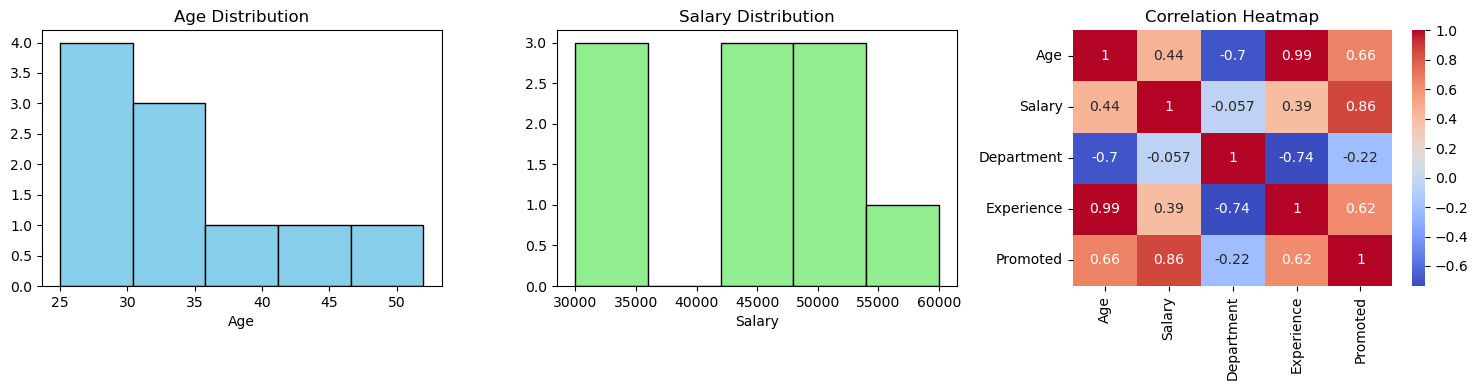

✅ Visualizations Done!


In [5]:
# STEP 5 - VISUALIZATION

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 - Age Distribution
axes[0].hist(df['Age'], bins=5, color='skyblue', edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

# Plot 2 - Salary Distribution  
axes[1].hist(df['Salary'], bins=5, color='lightgreen', edgecolor='black')
axes[1].set_title('Salary Distribution')
axes[1].set_xlabel('Salary')

# Plot 3 - Correlation Heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', ax=axes[2])
axes[2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('task1_visualization.png')
plt.show()
print("✅ Visualizations Done!")

In [6]:
# STEP 6 - SAVE PROCESSED DATA

df.to_csv('processed_data.csv', index=False)
print("✅ Processed Data Saved as 'processed_data.csv'")
print("\n" + "="*50)
print("🏁 TASK 1 - DATA PIPELINE COMPLETE!")
print("="*50)
print("✅ Extract   - Raw data created with missing values")
print("✅ Transform - Data cleaned, encoded, scaled")
print("✅ Load      - Processed data saved to CSV")
print("✅ Model     - Logistic Regression Pipeline trained")
print(f"✅ Accuracy  - {acc * 100:.2f}%")
print("="*50)
print("👨‍💻 Intern: Vivek Dipak Kshirsagar | CTIS6665")

✅ Processed Data Saved as 'processed_data.csv'

🏁 TASK 1 - DATA PIPELINE COMPLETE!
✅ Extract   - Raw data created with missing values
✅ Transform - Data cleaned, encoded, scaled
✅ Load      - Processed data saved to CSV
✅ Model     - Logistic Regression Pipeline trained
✅ Accuracy  - 100.00%
👨‍💻 Intern: Vivek Dipak Kshirsagar | CTIS6665
